In [1]:
import numpy as np
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import pickle

from spectral.io import envi
from spectral.io.envi import read_envi_header

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

os.chdir('/store/carroll/col')

In [2]:
out_figs = 'figs/'

wl = np.loadtxt('data/wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('data/wl_nan.txt')

base_dir = 'data/test_rccs/'

# prepare representative single pxs
fp = 'data/2025/validation/mineral_exposure_rdn_obs_loc.pkl'
with open(fp, 'rb') as f:
    single_px = pickle.load(f)    
    
fp = 'data/2025/validation/mineral_exposure_bboxes.pkl'
with open(fp, 'rb') as f:
    bboxes = pickle.load(f)

In [3]:
fids = [fid for fid in single_px.keys()]
sites = ['iron_gossan','lower_slate']
sites, fids

(['iron_gossan', 'lower_slate'],
 ['NIS01_20180621_172130_iron_gossan',
  'NIS01_20180621_171102_iron_gossan',
  'NIS01_20180625_173511_iron_gossan',
  'NIS01_20180625_174520_iron_gossan',
  'NIS01_20180621_174123_lower_slate',
  'NIS01_20180621_175122_lower_slate',
  'NIS01_20180625_171533_lower_slate',
  'NIS01_20250629_163144_CRBU_DP1_L048-1_iron_gossan',
  'NIS01_20250630_155622_CRBU_DP1_L049-1_iron_gossan',
  'NIS01_20250629_153839_CRBU_DP1_L043-1_lower_slate',
  'NIS01_20250629_154915_CRBU_DP1_L044-1_lower_slate',
  'NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate'])

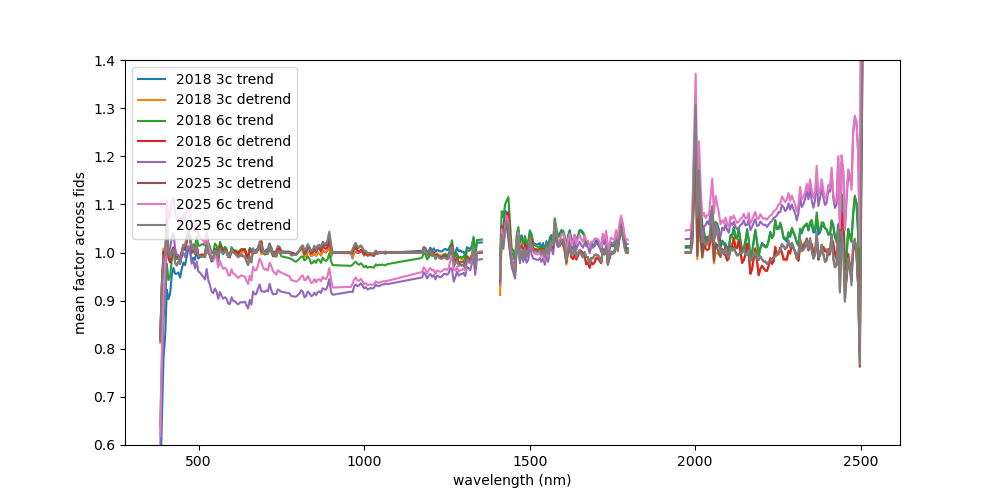

In [4]:
# load all rccs

fp = 'data/test_rccs/insitu_rccs_3c6c_mean.pkl'
with open(fp, 'rb') as f:
    rccs = pickle.load(f)
    
fig = plt.figure(figsize=(10,5))

year='2018'; emulator='3c'; trend='trend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2018'; emulator='3c'; trend='detrend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2018'; emulator='6c'; trend='trend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2018'; emulator='6c'; trend='detrend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2025'; emulator='3c'; trend='trend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2025'; emulator='3c'; trend='detrend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2025'; emulator='6c'; trend='trend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

year='2025'; emulator='6c'; trend='detrend'
rcc = rccs[year][emulator][trend]
plt.plot(wl_nan, rcc, label=f'{year} {emulator} {trend}')

plt.xlabel('wavelength (nm)')
plt.ylabel('mean factor across fids')
plt.ylim(0.6,1.4)
plt.legend()
plt.show()

In [ ]:
# for each single px, get the 3c and the 6c retrieval, with and without detrended rccs

In [5]:
fids_lis = []
years_lis = []
trends_lis = []
emulators_lis = []
alg_rfls_lis = []

for t in ['trend','detrend']:
    
    for fid in fids:
        
        fp_configs = glob(os.path.join(base_dir, f'{fid}*', 'config', '*_isofit.json'))
        
        for fp in fp_configs:
            if '6c' in fp:
                emulator='6c'
            else:
                emulator='3c'
            if '2018' in fp:
                year='2018'
            else:
                year='2025'
            print(t, fid, emulator, year)
            rcc_ = rccs[year][emulator][t]
            
            config = configs.create_new_config(fp)
    
            # set up forward model, io, inv according to config
            fm = ForwardModel(config) # loads pre-built LUT
            io = IO(config, fm)
            inv = Inversion(config, fm)
    
             # load the single pixel representation
            rdn_ = single_px[fid]['rdn']
            obs_ = single_px[fid]['obs']
            loc_ = single_px[fid]['loc']
            geom = Geometry(obs=obs_, loc=loc_)
            
            # adjust rdn
            meas = rdn_.copy()
            meas = meas*rcc_
            
            # retrieve rfl
            states=inv.invert(meas, geom)
            xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
            x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
            
            alg_rfls_lis.append(x_alg)
            years_lis.append(year)
            emulators_lis.append(emulator)
            trends_lis.append(t)
            fids_lis.append(fid)

INFO:root:Loading config file: data/test_rccs/NIS01_20180621_172130_iron_gossan/config/NIS01_20180621_172130_isofit.json
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20180621_172130_iron_gossan/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


trend NIS01_20180621_172130_iron_gossan 3c 2018


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20180621_172130_iron_gossan_6c/config/NIS01_20180621_172130_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20180621_172130_iron_gossan_6c/data/wavelengths.txt
INFO:/store/carroll/

trend NIS01_20180621_172130_iron_gossan 6c 2018


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20180621_171102_iron_gossan/config/NIS01_20180621_171102_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20180621_171102_iron_gossan/data/wavelengths.txt
INFO:/store/carroll/minifo

...

INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate/config/NIS01_20250629_160003_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate/data/wavelength

detrend NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate 3c 2025


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: data/test_rccs/NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate_6c/config/NIS01_20250629_160003_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/test_rccs/NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate_6c/data/wave

detrend NIS01_20250629_160003_CRBU_DP1_L045-1_lower_slate 6c 2025


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
df = pd.DataFrame({
    "year": years_lis,
    "emulator": emulators_lis,
    "fid": fids_lis,
    "trend_status": trends_lis
})

In [7]:
X = np.vstack(alg_rfls_lis)
X.shape

(48, 426)

In [8]:
wl_cols = [f'w{x}' for x in wl]
rfl_df = pd.DataFrame(X, columns=wl, index=df.index)
df_out = pd.concat([df, rfl_df], axis=1)

In [9]:
fp_out = 'data/2025/validation/mineral_exposure_rfl.csv'
df_out.to_csv(fp_out, index=False)

In [10]:
fp = 'data/2025/validation/mineral_exposure_rfl.csv'
df = pd.read_csv(fp)
bad = 'NIS01_20250629_163144_CRBU_DP1_L048-1_iron_gossan' # cloudy
df = df[df.fid!=bad]
df['site'] = ['_'.join(x.split('_')[-2:]) for x in df['fid']]
wvl_cols = [x for x in df.columns if '.' in x]
id_cols = [x for x in df.columns if x not in wvl_cols]
len(wvl_cols), len(id_cols)

(426, 5)

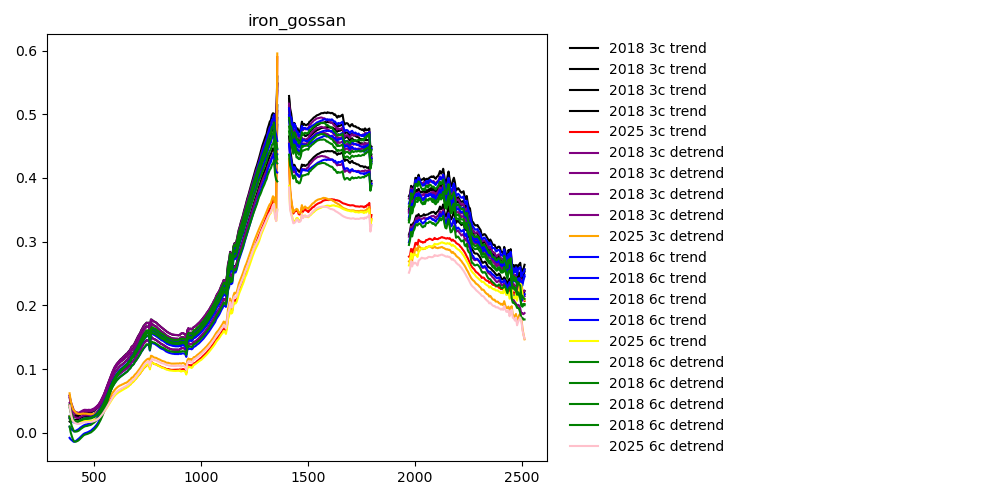

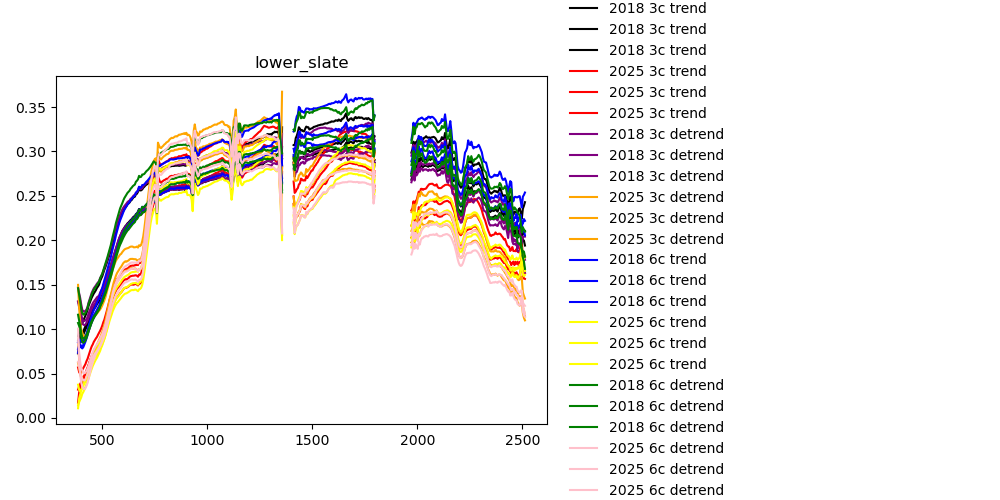

In [11]:
for site in sites:
    fig = plt.figure(figsize=(10,5))

    df_ = df[df['site']==site]

    # 3c, trend
    year=2018; emulator='3c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='black')
    year=2025; emulator='3c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='red')
    
    # 3c, detrend
    year=2018; emulator='3c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='purple')
    year=2025; emulator='3c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='orange')

    # 6c, trend
    year=2018; emulator='6c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='blue')
    year=2025; emulator='6c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='yellow')
    
    # 6c, detrend
    year=2018; emulator='6c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='green')

    year=2025; emulator='6c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='pink')
    

    plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout(rect=[0, 0, 0.75, 1])

    plt.title(site)
    plt.show

In [20]:
# get means per column

group_cols = ['year', 'emulator', 'trend_status', 'site']
df_mean = (
    df
    .groupby(group_cols, as_index=False)[wvl_cols]
    .mean()
)

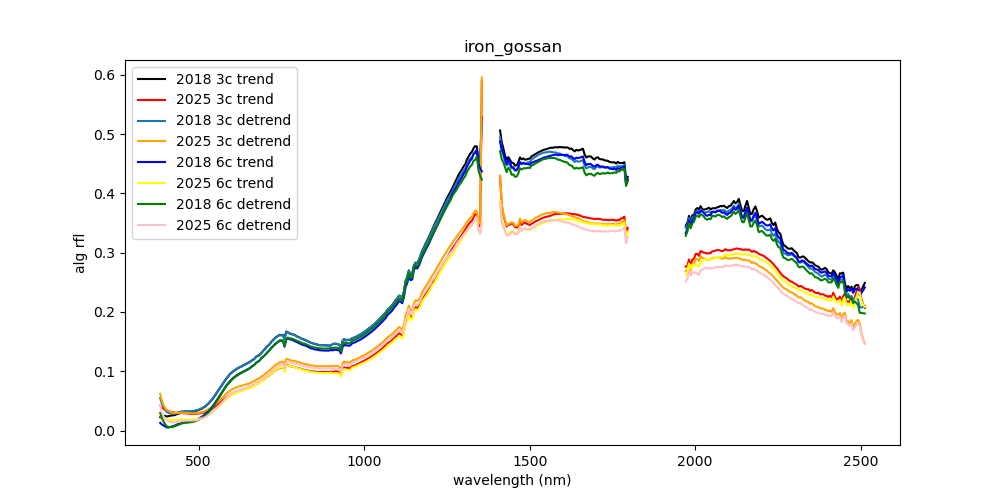

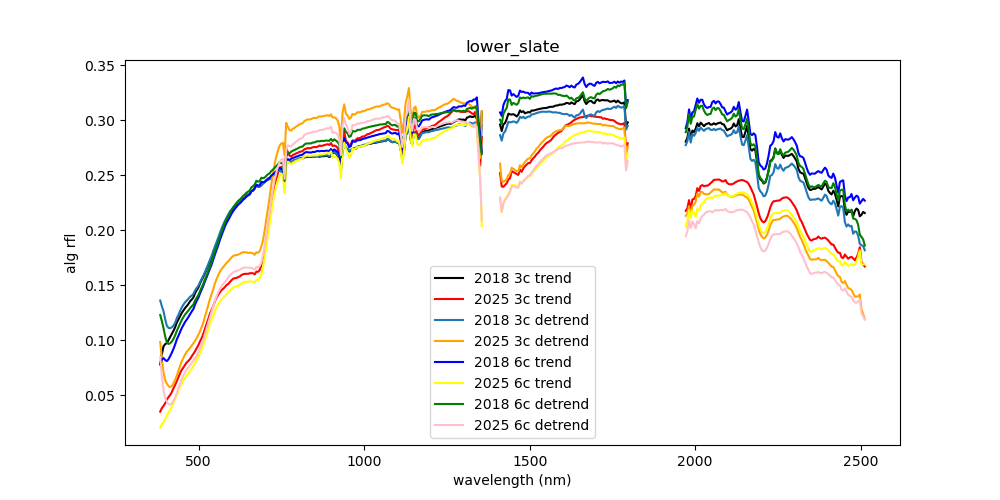

In [21]:
for site in sites:
    fig = plt.figure(figsize=(10,5))

    df_ = df_mean[df_mean['site']==site]

    # 3c, trend
    year=2018; emulator='3c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='black')
    year=2025; emulator='3c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='red')
    
    # 3c, detrend
    year=2018; emulator='3c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}')
    year=2025; emulator='3c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='orange')

    # 6c, trend
    year=2018; emulator='6c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='blue')
    year=2025; emulator='6c'; trend_status='trend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='yellow')
    
    # 6c, detrend
    year=2018; emulator='6c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='green')
    year=2025; emulator='6c'; trend_status='detrend'
    rfl = df_[(df_['year']==year) & (df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{year} {emulator} {trend_status}', color='pink')
    
    plt.legend()
    
    plt.xlabel('wavelength (nm)')
    plt.ylabel('alg rfl')
    
    plt.title(site)
    plt.show

In [14]:
# get the delta between group means over years

group_cols  = ['emulator', 'trend_status', 'site']
wide = (
    df_mean
    .set_index(group_cols + ['year'])[wvl_cols]
    .unstack('year') # columns become a MultiIndex: (wvl, year)
)

# delta = 2025 - 2018, for every wavelength column
delta = wide.xs(2025, level='year', axis=1) - wide.xs(2018, level='year', axis=1)

df_delta = delta.reset_index()


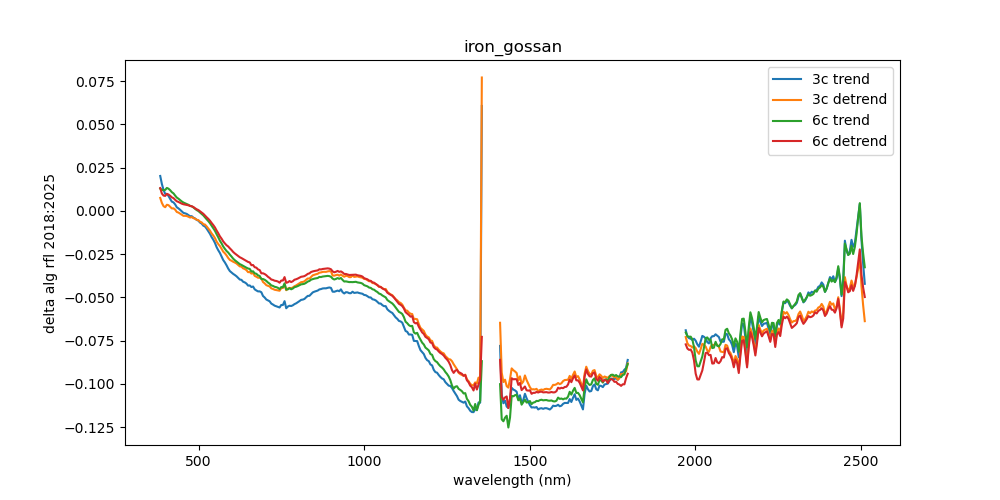

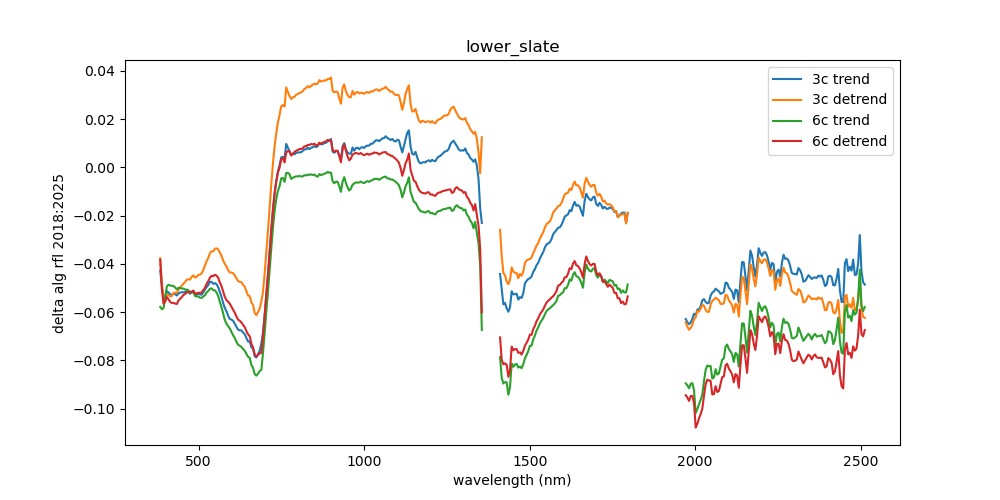

In [16]:
for site in sites:
    df_ = df_delta[df_delta['site']==site]
    
    fig = plt.figure(figsize=(10,5))

    # 3c, trend
    emulator='3c'; trend_status='trend'
    rfl = df_[(df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{emulator} {trend_status}')
    
    # 3c, detrend
    emulator='3c'; trend_status='detrend'
    rfl = df_[(df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{emulator} {trend_status}')

    # 6c, trend
    emulator='6c'; trend_status='trend'
    rfl = df_[(df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{emulator} {trend_status}')
    
    # 6c, detrend
    emulator='6c'; trend_status='detrend'
    rfl = df_[(df_['emulator']==emulator) & (df_['trend_status']==trend_status)][wvl_cols]
    plt.plot(wl_nan, rfl.T, label=f'{emulator} {trend_status}')   

    plt.xlabel('wavelength (nm)')
    plt.ylabel('delta alg rfl 2018:2025')
    plt.legend()
    plt.title(site)
    plt.show

In [17]:
wl = pd.to_numeric(df_delta.columns, errors='coerce')
mask_drop = (((wl >= 1345) & (wl <= 1420)) | ((wl >= 1800) & (wl <= 1970)))

df_delta_na = df_delta.loc[:, ~mask_drop].copy()
wvl_cols_na = [x for x in df_delta_na.columns if '.' in x]
len(wvl_cols_na)

377

In [18]:
df_delta_na['sum'] = df_delta_na[wvl_cols_na].abs().sum(axis=1)

df_delta_na['label'] = (
    df_delta_na[['emulator','trend_status','site']]
    .fillna('')
    .astype(str)
    .agg('_'.join, axis=1)
    .str.strip('_')
)
df_delta_na[['sum', 'label']]

,sum,label
0,22.835363,3c_detrend_iron_gossan
1,13.977746,3c_detrend_lower_slate
2,24.205362,3c_trend_iron_gossan
3,12.103604,3c_trend_lower_slate
4,23.126420,6c_detrend_iron_gossan
5,17.786619,6c_detrend_lower_slate
6,22.986215,6c_trend_iron_gossan
7,17.637380,6c_trend_lower_slate


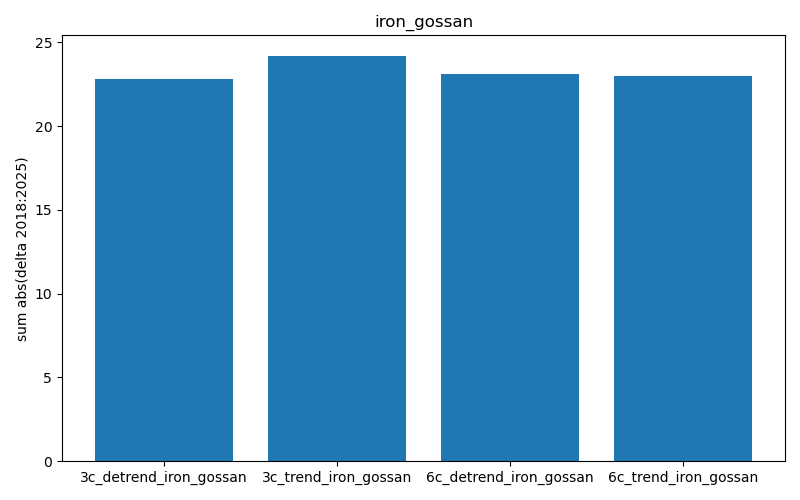

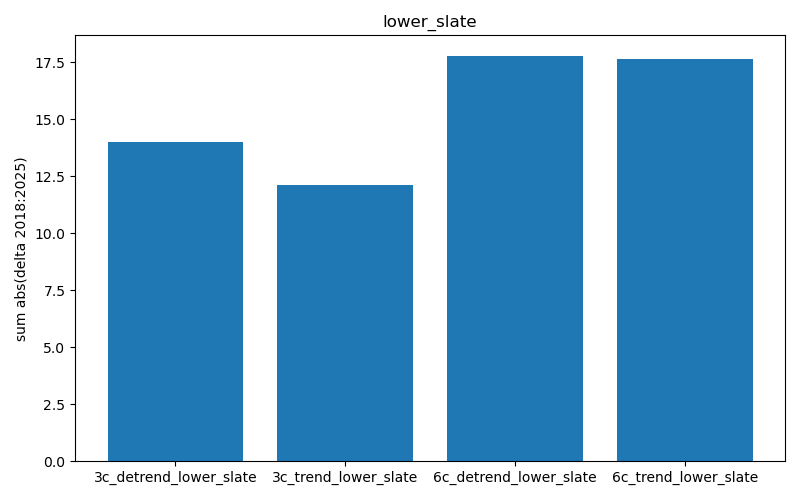

In [19]:
for site in sites:
    df_ = df_delta_na[df_delta_na['site']==site]
    
    fig = plt.figure(figsize=(8,5))

    plt.bar(df_['label'], df_['sum'])

    plt.ylabel('sum abs(delta 2018:2025)')
    plt.title(site)
    plt.tight_layout()

    plt.show

In [29]:
emulator='3c'; trend_status='trend'; site='iron_gossan'; year=2018
rfl_gossan_3c_2018 = np.array(df_mean[(df_mean['emulator']==emulator) & (df_mean['trend_status']==trend_status) & (df_mean['year']==year) & (df_mean['site']==site)][wvl_cols])

emulator='3c'; trend_status='detrend'; site='iron_gossan'; year=2025
rfl_gossan_3c_2025 = np.array(df_mean[(df_mean['emulator']==emulator) & (df_mean['trend_status']==trend_status) & (df_mean['year']==year) & (df_mean['site']==site)][wvl_cols])

delta_gossan_3c = rfl_gossan_3c_2025 - rfl_gossan_3c_2018

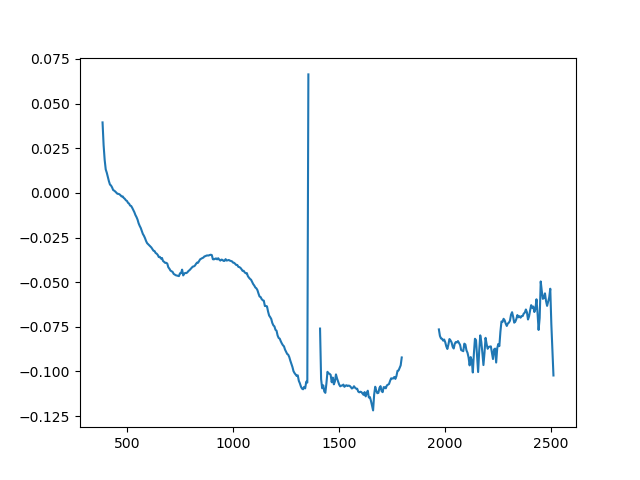

In [30]:
fig = plt.figure()

plt.plot(wl_nan, delta_gossan_3c.T)

plt.show()